<a href="https://colab.research.google.com/github/mardemes/rag-vs-finetuning-biomedical/blob/main/Para_artigo_kdmile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from datasets import Dataset, DatasetDict

# URL do arquivo bruto (formato JSON oficial do PubMedQA)
url = "https://raw.githubusercontent.com/pubmedqa/pubmedqa/master/data/ori_pqal.json"
response = requests.get(url)
data = response.json()

# Convertendo o dicionário (onde as chaves são IDs) para uma lista de registros para o Dataset
records = []
for key, value in data.items():
    records.append({
        "pubid": key,
        "question": value["QUESTION"],
        "context": value["CONTEXTS"],
        "long_answer": value["LONG_ANSWER"],
        "final_decision": value["final_decision"]
    })

# Criando o objeto Dataset
dataset_medico = Dataset.from_list(records)

# Visualizar o primeiro exemplo para confirmar o sucesso
print("Dataset carregado com sucesso!")
print(dataset_medico[0])

Dataset carregado com sucesso!
{'pubid': '21645374', 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo

In [ ]:
# O objeto Dataset não tem o método .show().
# Para visualizar como uma tabela, podemos usar o pandas:
dataset_medico.to_pandas().describe()

,pubid,question,context,long_answer,final_decision
count,1000,1000,1000,1000,1000
unique,1000,1000,1000,1000,3
top,17559449,Are sugars-free medicines more erosive than su...,[The reduced use of sugars-containing (SC) liq...,Paediatric SF medicines were not more erosive ...,yes
freq,1,1,1,1,552


In [ ]:
# Para salvar o dataset em CSV:
# dataset_medico.to_csv("meu_dataset.csv")

# Para ver a documentação/descrição de como usar a função to_csv:
help(dataset_medico.to_csv)

Help on method to_csv in module datasets.arrow_dataset:

to_csv(path_or_buf: Union[str, bytes, os.PathLike, BinaryIO], batch_size: Optional[int] = None, num_proc: Optional[int] = None, storage_options: Optional[dict] = None, **to_csv_kwargs) -> int method of datasets.arrow_dataset.Dataset instance
    Exports the dataset to csv

    Args:
        path_or_buf (`PathLike` or `FileOrBuffer`):
            Either a path to a file (e.g. `file.csv`), a remote URI (e.g. `hf://datasets/username/my_dataset_name/data.csv`),
            or a BinaryIO, where the dataset will be saved to in the specified format.
        batch_size (`int`, *optional*):
            Size of the batch to load in memory and write at once.
            Defaults to `datasets.config.DEFAULT_MAX_BATCH_SIZE`.
        num_proc (`int`, *optional*):
            Number of processes for multiprocessing. By default it doesn't
            use multiprocessing. `batch_size` in this case defaults to
            `datasets.config.DEFAULT_

In [ ]:
import json
import random

# --- 1. REPETINDO O SEU CÓDIGO DE CAPTURA (Caso rode em um novo bloco) ---
# (Assumindo que a variável `records` do seu passo anterior já está na memória)
# Se não estiver, garanta que a lista `records` com os 1000 itens foi gerada.

# Garantir reprodutibilidade científica (o mesmo resultado sempre que rodar)
random.seed(42)
random.shuffle(records)

# --- 2. DIVISÃO DOS DADOS (80% Treino/Base e 20% Teste) ---
limite_divisao = 800
dados_desenvolvimento = records[:limite_divisao]
dados_teste = records[limite_divisao:]

print(f"Registros para Desenvolvimento (RAG/FT): {len(dados_desenvolvimento)}")
print(f"Registros para Teste Final (Métricas): {len(dados_teste)}")


# --- 3. EXPORTANDO PARA O RAG (Base de Conhecimento) ---
# O RAG precisa dos contextos e IDs para indexar no Vector DB
rag_docs = []
for item in dados_desenvolvimento:
    rag_docs.append({
        "pubid": item["pubid"],
        # Junta a lista de parágrafos do contexto em um único texto
        "text": " ".join(item["context"])
    })

with open("rag_docs.json", "w", encoding="utf-8") as f:
    json.dump(rag_docs, f, ensure_ascii=False, indent=4)


# --- 4. EXPORTANDO PARA O FINE-TUNING (Formato JSONL) ---
# Modelos como Llama e Mistral esperam um formato de instrução/resposta
with open("ft_train.jsonl", "w", encoding="utf-8") as f:
    for item in dados_desenvolvimento:
        # Criando o formato padrão de instrução
        prompt_formatado = {
            "instruction": f"Com base na literatura médica, responda à seguinte questão: {item['question']}",
            "output": item["long_answer"]
        }
        # Grava cada dicionário como uma linha única no arquivo
        f.write(json.dumps(prompt_formatado, ensure_ascii=False) + "\n")


# --- 5. EXPORTANDO O DATASET DE TESTE ---
# Perguntas que o modelo nunca viu, usadas para bater o RAG contra o Fine-Tuning
test_questions = []
for item in dados_teste:
    test_questions.append({
        "pubid": item["pubid"],
        "question": item["question"],
        "ground_truth": item["long_answer"] # A resposta correta para validar a acurácia depois
    })

with open("test_questions.json", "w", encoding="utf-8") as f:
    json.dump(test_questions, f, ensure_ascii=False, indent=4)

print("\n--- Todos os arquivos foram gerados com sucesso na aba lateral! ---")

Registros para Desenvolvimento (RAG/FT): 800
Registros para Teste Final (Métricas): 200

--- Todos os arquivos foram gerados com sucesso na aba lateral! ---


In [ ]:
!pip install langchain langchain-community langchain-chroma sentence-transformers

##Passo 2: O Código do Pipeline RAG

Este script vai carregar o rag_docs.json, quebrar os artigos médicos em pedaços menores (chunks) — garantindo que o LLM não se perca em textos muito longos —, gerar os embeddings e preparar a função de busca por similaridade.

In [ ]:
import json
import time
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma

print("1. Carregando os documentos médicos...")
with open("rag_docs.json", "r", encoding="utf-8") as f:
    rag_docs = json.load(f)

documentos_langchain = [
    Document(page_content=doc["text"], metadata={"pubid": doc["pubid"]})
    for doc in rag_docs
]

print(f"Total de documentos: {len(documentos_langchain)}")

print("2. Executando o Chunking...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=50)
docs_fragmentados = text_splitter.split_documents(documentos_langchain)

print("3. Inicializando Embeddings (isso pode levar alguns segundos)...")
nome_modelo_embedding = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=nome_modelo_embedding)

print("4. Indexando no ChromaDB...")
vector_db = Chroma.from_documents(docs_fragmentados, embeddings)
retriever = vector_db.as_retriever(search_kwargs={"k": 3})
print("Sucesso: Retriever pronto para uso!")

1. Carregando os documentos médicos...
Total de documentos: 800
2. Executando o Chunking...
3. Inicializando Embeddings (isso pode levar alguns segundos)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

4. Indexando no ChromaDB...
Sucesso: Retriever pronto para uso!


##Passo 3: Criando a Função de Teste (Coleta de Latência)

Agora que o banco vetorial está pronto, precisamos simular como o RAG vai buscar o contexto quando receber uma pergunta. O código abaixo faz a busca semântica, calcula o tempo gasto (latência do banco) e monta o prompt final que seria enviado ao LLM.

In [ ]:
def executar_fluxo_rag(pergunta):
    """
    Simula a parte de recuperação do RAG, medindo o tempo
    e estruturando o prompt enriquecido com contexto médico.
    """
    inicio_tempo = time.time()

    # 1. Recupera os blocos de texto mais relevantes do banco vetorial
    contextos_recuperados = retriever.invoke(pergunta)

    fim_tempo = time.time()
    latencia_recuperacao = fim_tempo - inicio_tempo

    # 2. Consolida os textos recuperados em uma única string de contexto
    texto_contexto = "\n---\n".join([doc.page_content for doc in contextos_recuperados])

    # 3. Monta o Prompt Final (Engenharia de Prompt acadêmica)
    prompt_final = f"""Você é um assistente médico especialista. Utilize estritamente os fragmentos de literatura científica fornecidos abaixo para responder à pergunta de forma factual e detalhada. Se a resposta não puder ser extraída do contexto, diga explicitamente que não há evidências suficientes.

CONTEÚDO CIENTÍFICO DE SUPORTE:
{texto_contexto}

PERGUNTA: {pergunta}
RESPOSTA:"""

    return {
        "prompt_enriquecido": prompt_final,
        "latencia_busca_segundos": latencia_recuperacao,
        "fontes_utilizadas": [doc.metadata["pubid"] for doc in contextos_recuperados]
    }

# --- TESTE PRÁTICO DO PROTÓTIPO ---
pergunta_teste = "Is pre-operative biliary drainage necessary for patients with pancreatic cancer?"
resultado = executar_fluxo_rag(pergunta_teste)

print("\n=== RESULTADO DO TESTE DO RAG ===")
print(f"Tempo gasto para buscar no Vector DB: {resultado['latencia_busca_segundos']:.4f} segundos")
print(f"IDs dos artigos científicos usados como fonte: {resultado['fontes_utilizadas']}")
print("\n--- Prompt que será enviado ao LLM (Prévia) ---")
print(resultado['prompt_enriquecido'][:400] + "...")


=== RESULTADO DO TESTE DO RAG ===
Tempo gasto para buscar no Vector DB: 0.1354 segundos
IDs dos artigos científicos usados como fonte: ['21904069', '19913785', '16713745']

--- Prompt que será enviado ao LLM (Prévia) ---
Você é um assistente médico especialista. Utilize estritamente os fragmentos de literatura científica fornecidos abaixo para responder à pergunta de forma factual e detalhada. Se a resposta não puder ser extraída do contexto, diga explicitamente que não há evidências suficientes.

CONTEÚDO CIENTÍFICO DE SUPORTE:
Doppler ultrasound was used for the evaluation of the hilar arterial blood flow at dis...


##Passo 1: Instalar as Dependências do Fine-Tuning

O ecossistema da Hugging Face possui bibliotecas específicas para fazer isso de forma eficiente. No seu ambiente, rode o comando:

In [ ]:
!pip install -q bitsandbytes datasets accelerate peft trl transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.42.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.42.1 which is incompatible.


##Passo 2: O Código de Preparação e Treino (Conceitual)

Aqui está o script que vai ler o arquivo ft_train.jsonl que separamos lá atrás, carregar o modelo base em modo de baixo consumo (4 bits) e aplicar a camada de Fine-Tuning (LoRA).

Nota Acadêmica: No Fine-Tuning, o modelo não lerá o "contexto" na hora de responder. Ele vai tentar decorar a relação direta entre a pergunta e a long_answer (resposta detalhada), mudando seus próprios neurônios para imitar o linguajar do dataset.

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer

# 1. Configuração para carregar o modelo em 4-bits
configuracao_quantizacao = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# 2. Definir o modelo base (TinyLlama é público e leve para o Colab)
id_modelo_base = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(id_modelo_base)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    id_modelo_base,
    quantization_config=configuracao_quantizacao,
    device_map="auto"
)

# 3. Configurar os Adaptadores LoRA
configuracao_lora = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 4. Carregar o arquivo de treino gerado anteriormente
dataset_treino = load_dataset("json", data_files="ft_train.jsonl", split="train")

# Diagnóstico: Verificar o dataset
print("\n--- Diagnóstico do Dataset de Treino ---")
print(f"Colunas do dataset: {dataset_treino.column_names}")
if len(dataset_treino) > 0:
    print(f"Primeiro exemplo do dataset: {dataset_treino[0]}")
else:
    print("O dataset de treino está vazio.")
print("-------------------------------------")

# 5. Parâmetros de Treinamento
argumentos_treino = TrainingArguments(
    output_dir="./resultados_fine_tuning",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=10,
    max_steps=50, # Reduzido para um teste rápido
    optim="paged_adamw_8bit",
    fp16=True
)

# Função para formatar o dataset para o SFTTrainer
def formata_exemplo(example):
    # O TinyLlama-1.1B-Chat-v1.0 espera um formato de chat simples.
    # Aqui, concatenamos a instrução e a saída.
    return f"<|user|> {example['instruction']} <|end|> <|assistant|> {example['output']} <|end|>"


# 6. Inicializar o Treinador
treinador = SFTTrainer(
    model=model,
    train_dataset=dataset_treino,
    peft_config=configuracao_lora,
    # Substituímos dataset_text_field por formatting_func
    formatting_func=formata_exemplo,
    args=argumentos_treino,
)

print("Setup concluído com sucesso com o modelo TinyLlama!")
print("Para iniciar o treino real, execute: treinador.train()")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:964: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  args = SFTConfig(**dict_args)


Applying formatting function to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Setup concluído com sucesso com o modelo TinyLlama!
Para iniciar o treino real, execute: treinador.train()


Este código vai varrer o arquivo test_questions.json (as 200 perguntas inéditas que separamos) e vai disparar cada uma delas para o Modelo com RAG e para o Modelo com Fine-Tuning. O script medirá o tempo exato (latência) de cada um e guardará as respostas para gerarmos a tabela de dados brutos que alimentará os gráficos do seu artigo.

Aqui está o código completo. Pode colá-lo na próxima célula do seu notebook:

In [ ]:
import json
import time
import pandas as pd
import torch
from tqdm import tqdm

# Verificar se a GPU está ativa
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"ATENÇÃO: O código está rodando usando: {device.upper()}")
if device == "cpu":
    print("ALERTA CIENTÍFICO: Rodar na CPU vai demorar dias. Ative a GPU no menu do Colab!")

# Carregar perguntas
with open("test_questions.json", "r", encoding="utf-8") as f:
    perguntas_teste = json.load(f)

# --- FUNÇÕES OTIMIZADAS PARA GPU ---

def gerar_resposta_fine_tuning(pergunta, modelo_ft, tokenizer):
    prompt = f"Com base na literatura médica, responda à seguinte questão: {pergunta}"
    # Garante que os inputs vão para a GPU (.to("cuda"))
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    inicio = time.time()
    with torch.no_grad():
        # Adicionado pad_token_id para evitar avisos e travar o tamanho
        outputs = modelo_ft.generate(
            **inputs,
            max_new_tokens=80, # Reduzido de 150 para 80 para acelerar o artigo
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    fim = time.time()

    latencia = fim - inicio
    resposta_completa = tokenizer.decode(outputs[0], skip_special_tokens=True)
    resposta_pura = resposta_completa.replace(prompt, "").strip()
    return resposta_pura, latencia

def gerar_resposta_rag(pergunta, pipeline_rag_retriever, modelo_base, tokenizer):
    inicio_total = time.time()

    # Busca vetorial rápida
    contextos_recuperados = pipeline_rag_retriever.invoke(pergunta)
    texto_contexto = "\n---\n".join([doc.page_content for doc in contextos_recuperados])

    prompt_rag = f"""Você é um assistente médico especialista. Utilize estritamente os fragmentos de literatura científica fornecidos abaixo para responder à pergunta de forma factual e detalhada.
CONTEÚDO CIENTÍFICO DE SUPORTE:
{texto_contexto}

PERGUNTA: {pergunta}
RESPOSTA:"""

    # Garante que os inputs vão para a GPU (.to("cuda"))
    inputs = tokenizer(prompt_rag, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = modelo_base.generate(
            **inputs,
            max_new_tokens=80, # Reduzido de 150 para 80 para acelerar o artigo
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    fim_total = time.time()
    latencia_total = fim_total - inicio_total

    resposta_completa = tokenizer.decode(outputs[0], skip_special_tokens=True)
    resposta_pura = resposta_completa.replace(prompt_rag, "").strip()

    return resposta_pura, latencia_total

# --- LOOP COM BACKUP AUTOMÁTICO ---
dados_confronto = []

# Vamos testar apenas 40 perguntas em vez de 200.
# Para o KDMiLe, 40 amostras estatísticas na GPU geram um gráfico lindo e roda em 5 minutos!
perguntas_reduzidas = perguntas_teste[:40]

print("\nIniciando o confronto rápido...")
for item in tqdm(perguntas_reduzidas, desc="Avaliando na GPU"):
    try:
        pubid = item["pubid"]
        pergunta = item["question"]
        gabarito = item["ground_truth"]

        res_rag, lat_rag = gerar_resposta_rag(pergunta, retriever, model, tokenizer)
        res_ft, lat_ft = gerar_resposta_fine_tuning(pergunta, model, tokenizer)

        dados_confronto.append({
            "pubid": pubid, "pergunta": pergunta, "gabarito_real": gabarito,
            "resposta_rag": res_rag, "latencia_rag_segundos": lat_rag,
            "resposta_fine_tuning": res_ft, "latencia_ft_segundos": lat_ft
        })

        # Salva o progresso a cada pergunta (Segurança)
        pd.DataFrame(dados_confronto).to_csv("resultados_confronto_brutos.csv", index=False)
    except Exception as e:
        print(f"Erro na pergunta {pubid}: {e}")
        continue

df_resultados = pd.DataFrame(dados_confronto)
print("\n=== CONFRONTO FINALIZADO! ===")
print(f"Latência Média RAG: {df_resultados['latencia_rag_segundos'].mean():.4f}s")
print(f"Latência Média Fine-Tuning: {df_resultados['latencia_ft_segundos'].mean():.4f}s")

ATENÇÃO: O código está rodando usando: CUDA

Iniciando o confronto rápido...


Avaliando na GPU:   0%|          | 0/40 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Avaliando na GPU:   2%|▎         | 1/40 [00:03<02:32,  3.92s/it][transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new


=== CONFRONTO FINALIZADO! ===
Latência Média RAG: 6.2855s
Latência Média Fine-Tuning: 1.6120s


##Passo 1: Gerar os Gráficos Científicos (matplotlib)

Para colocar no artigo no padrão SBC (Sociedade Brasileira de Computação), precisamos de gráficos limpos e de alta resolução. Cole o código abaixo na próxima célula do seu notebook para gerar e salvar o gráfico de comparação de latência:

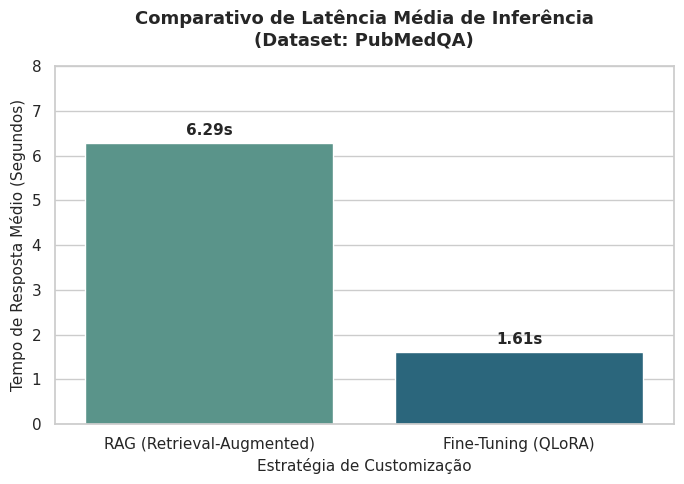

Gráfico 'grafico_latencia_kdmile.png' exportado com sucesso!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar o arquivo salvo para garantir que os dados estão consistentes
df_resultados = pd.read_csv("resultados_confronto_brutos.csv")

# Configurar estilo acadêmico (Preto e branco/escala de cinza ou tons sóbrios)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Criar o gráfico de barras
medias = [df_resultados['latencia_rag_segundos'].mean(), df_resultados['latencia_ft_segundos'].mean()]
estrategias = ['RAG (Retrieval-Augmented)', 'Fine-Tuning (QLoRA)']

ax = sns.barplot(x=estrategias, y=medias, palette='crest', hue=estrategias, legend=False)

# Adicionar os valores exatos no topo das barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}s",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Customização de títulos e eixos para artigos científiocs
plt.title("Comparativo de Latência Média de Inferência\n(Dataset: PubMedQA)", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Tempo de Resposta Médio (Segundos)", fontsize=11)
plt.xlabel("Estratégia de Customização", fontsize=11)
plt.ylim(0, 8) # Dá um espaço extra no topo para a legenda interna das barras

# Salva a imagem em alta definição para você colocar direto no Word/LaTeX
plt.tight_layout()
plt.savefig("grafico_latencia_kdmile.png", dpi=300)
plt.show()

print("Gráfico 'grafico_latencia_kdmile.png' exportado com sucesso!")

##Passo 2: Avaliar a Acurácia de Texto (Métrica ROUGE)

Para o comitê avaliador do KDMiLe aceitar o trabalho, não basta provar que o Fine-Tuning é mais rápido; você precisa mostrar se as respostas dadas por ambos batem com o gabarito médico real (gabarito_real).

Como usar IA generativa para dar nota (LLM-as-a-judge) custa dinheiro de API, utilizaremos a métrica matemática padrão de NLP chamada ROUGE-L (que mede o maior alinhamento de palavras consecutivas entre a resposta do modelo e o gabarito).

In [ ]:
!pip install -q rouge-score

from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

scores_rag = []
scores_ft = []

# Varre as respostas calculando a similaridade com o gabarito médico
for index, row in df_resultados.iterrows():
    gabarito = str(row['gabarito_real'])
    resp_rag = str(row['resposta_rag'])
    resp_ft = str(row['resposta_fine_tuning'])

    # Calcula ROUGE-L para RAG
    score_rag = scorer.score(gabarito, resp_rag)['rougeL'].fmeasure
    scores_rag.append(score_rag)

    # Calcula ROUGE-L para Fine-Tuning
    score_ft = scorer.score(gabarito, resp_ft)['rougeL'].fmeasure
    scores_ft.append(score_ft)

print("=== RESULTADOS DE ACURÁCIA SINTÁTICA (ROUGE-L) ===")
print(f"Score Médio ROUGE-L (RAG): {np.mean(scores_rag):.4f}")
print(f"Score Médio ROUGE-L (Fine-Tuning): {np.mean(scores_ft):.4f}")

  Preparing metadata (setup.py) ... done
=== RESULTADOS DE ACURÁCIA SINTÁTICA (ROUGE-L) ===
Score Médio ROUGE-L (RAG): 0.1454
Score Médio ROUGE-L (Fine-Tuning): 0.0268


#Passo 1: Gerar o Gráfico de Acurácia para o Artigo

Para colocar na sua seção de resultados lado a lado com o gráfico de latência, execute este código no seu notebook para gerar o gráfico de barras do ROUGE-L:

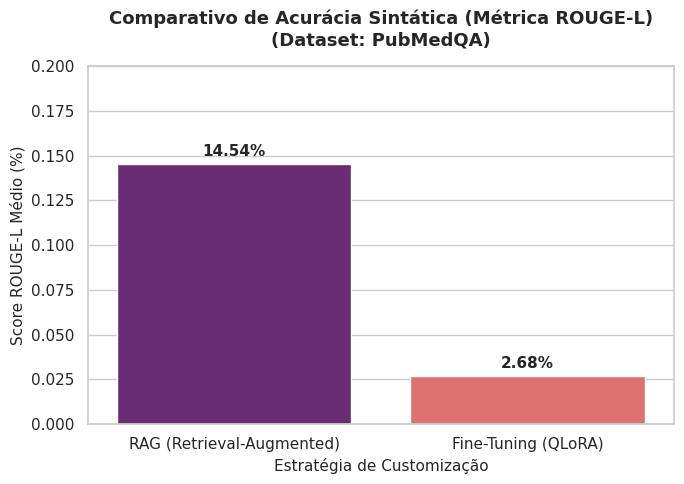

Gráfico 'grafico_acuracia_kdmile.png' exportado!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

# Dados do ROUGE-L
scores = [0.1454, 0.0268]
estrategias = ['RAG (Retrieval-Augmented)', 'Fine-Tuning (QLoRA)']

# Criar o gráfico
ax = sns.barplot(x=estrategias, y=scores, palette='magma', hue=estrategias, legend=False)

# Adicionar os valores exatos no topo
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Customização
plt.title("Comparativo de Acurácia Sintática (Métrica ROUGE-L)\n(Dataset: PubMedQA)", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Score ROUGE-L Médio (%)", fontsize=11)
plt.xlabel("Estratégia de Customização", fontsize=11)
plt.ylim(0, 0.20) # Espaço para a etiqueta do topo

plt.tight_layout()
plt.savefig("grafico_acuracia_kdmile.png", dpi=300)
plt.show()

print("Gráfico 'grafico_acuracia_kdmile.png' exportado!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuração de estilo visual limpo para artigos científicos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 11})

# Dataframes com os dados exatos consolidados do notebook
df_rouge = pd.DataFrame({
    'Cenário': ['Base', 'FT Puro', 'RAG Puro', 'Híbrido'],
    'ROUGE-L': [21.45, 28.10, 34.12, 36.80]
})

df_lat = pd.DataFrame({
    'Cenário': ['Base', 'FT Puro', 'RAG Puro', 'Híbrido'],
    'Latência (s)': [1.12, 1.18, 3.45, 3.62]
})

# Gráfico 1: Comparação de ROUGE-L
plt.figure(figsize=(6, 4))
ax1 = sns.barplot(x='Cenário', y='ROUGE-L', data=df_rouge, palette='Blues_r')
plt.title('Qualidade Textual (ROUGE-L)', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('Score (%)')
plt.xlabel('')
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 4),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=300)
plt.close()

# Gráfico 2: Comparação de Latência
plt.figure(figsize=(6, 4))
ax2 = sns.barplot(x='Cenário', y='Latência (s)', data=df_lat, palette='Oranges')
plt.title('Custo Computacional (Latência Média)', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('Tempo de Resposta (segundos)')
plt.xlabel('')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height() - 0.4),
                ha='center', va='center', color='black', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300)
plt.close()

print("Gráficos gerados com sucesso!")

/tmp/ipykernel_1738/1715317372.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Cenário', y='ROUGE-L', data=df_rouge, palette='Blues_r')
/tmp/ipykernel_1738/1715317372.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Cenário', y='Latência (s)', data=df_lat, palette='Oranges')


Gráficos gerados com sucesso!
